# 15c · GSE232381 · bulk_RNA_seq · where the 28 interferon response genes land

Reads `wgcna_input.rds`, `modules.rds`, `expression.rds`, `projected_scores.rds` in `data/run_artifacts/GSE232381/`, and the gene lists in `genes/`. Writes a figure to `figures/GSE232381/`.

**Gene lists**
- `ifn-response-genes-28.txt`: the 28 interferon response genes. The same 28 genes are listed in Kim H et
  al. *J Interferon Cytokine Res* 2018;38:171-185 (Supplementary Table S1) and in de Jesus AA et al.
  *J Clin Invest* 2020;130:1669-1682 (Supplemental Figure 3B).
- The two papers define different 25-gene subsets:
  - Kim 2018 (`ifn-response-genes-25-kim2018.txt`): the 28 without EPSTI1, SIGLEC1 and SPATS2L, the three
    genes added from the literature.
  - de Jesus 2020 (`ifn-response-genes-25-stat1-only-dejesus2020.txt`): the 28 without CXCL10, GBP1 and
    SOCS1 (`ifn-response-genes-3-stat1-nfkb-dejesus2020.txt`), the genes with STAT1 and NF-kB binding sites.
- `nfkb-only-control-11-dejesus2020.txt`: 11 NF-kB target genes with no STAT1, STAT2 or TYK1 binding site
  (de Jesus 2020, Methods Step 2 and Supplemental Figure 5). They are the control.

The header of each gene file gives the sources and the differences between the two papers.

**What is reported for each gene.** Whether it is measured in this study, whether it is in the WGCNA
network, its module, and its kME with the interferon module: the Pearson correlation of the gene with the
module eigengene over the 25 samples (Horvath S, Dong J. *PLoS Comput Biol* 2008;4:e1000117). For this
study, also its Pearson correlation with the GSE65391 interferon module (black) projected into these samples (notebook
15b). No test is done; this is a description.

## Load the gene lists

In [1]:
source("../src/paths.R")
G <- "GSE232381"
irg28  <- read_gene_set("ifn-response-genes-28.txt")
kim25  <- read_gene_set("ifn-response-genes-25-kim2018.txt")
dj3    <- read_gene_set("ifn-response-genes-3-stat1-nfkb-dejesus2020.txt")
nfkb11 <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
g <- data.frame(set = rep(c("IRG-28", "NF-kB-11"), c(length(irg28), length(nfkb11))), gene = c(irg28, nfkb11))
g$kim2018_25 <- ifelse(g$set == "IRG-28", g$gene %in% kim25, NA)
g$dejesus2020_subscore <- ifelse(g$set == "IRG-28", ifelse(g$gene %in% dj3, "3 STAT1/NF-kB", "25 STAT1-only"), "")
table(g$set)


  IRG-28 NF-kB-11 
      28       11 

**Explanation**
- `source("../src/paths.R")` loads the locations and helpers (see notebook 00).
- `read_gene_set()` returns the gene symbols in a file of `genes/` (see notebook 00).
- `data.frame(set = ..., gene = ...)` makes one row per gene. `rep(c("IRG-28", "NF-kB-11"), c(28, 11))`
  repeats each label as many times as there are genes in its list.
- `kim2018_25` is TRUE for genes in Kim's 25-gene score. It is NA for the control genes.
- `dejesus2020_subscore` is "3 STAT1/NF-kB" for CXCL10, GBP1 and SOCS1, and "25 STAT1-only" for the other 25.
- `table(g$set)` counts the genes in each list: 28 and 11.

## Match the genes to this study

In [2]:
w <- readRDS(art(G, "wgcna_input.rds"))
m <- readRDS(art(G, "modules.rds"))
e <- readRDS(art(G, "expression.rds"))
g$measured   <- g$gene %in% rownames(e$E)
g$in_network <- g$gene %in% colnames(w$datExpr)
g$module     <- ifelse(g$in_network, unname(m$colors[g$gene]), NA)
c(samples_in_network = nrow(w$datExpr), genes_in_network = ncol(w$datExpr))

samples_in_network   genes_in_network 
                25              13578

**Explanation**
- `readRDS()` reads an R object saved by an earlier notebook. `art(G, file)` gives its path (see notebook 00).
  - `wgcna_input.rds` holds `datExpr`, the samples by genes matrix used for WGCNA.
  - `modules.rds` holds `colors`, the module of each gene, and `kME`, each gene's correlation with each module
    eigengene.
  - `expression.rds` holds `E`, all measured genes.
- `%in%` is TRUE where a gene is found in the other list.
- `measured`: the gene is in this study's expression table.
- `in_network`: the gene passed the filters of notebooks 12 and 13 and is in the WGCNA network.
- `module`: the gene's module; NA if it is not in the network. `unname()` drops the gene names that
  `m$colors[...]` carries.

## Find the interferon module

In [3]:
irg_modules <- sort(table(g$module[g$set == "IRG-28"]), decreasing = TRUE)
irg_modules
ifn_module <- names(irg_modules)[1]
ifn_module


 lightgreen   turquoise        blue       brown        grey lightyellow 
         19           4           1           1           1           1 
  royalblue 
          1 

[1] "lightgreen"

**Explanation**
- `table()` counts how many of the 28 genes fall in each module; `sort(..., decreasing = TRUE)` puts the
  largest count first.
- The interferon module is defined as the module that holds the most of the 28 genes.
  `names(irg_modules)[1]` is its name.

## Correlation of each gene with the interferon module

In [4]:
net <- g$gene[g$in_network]
g$kME_ifn <- NA_real_
g$kME_ifn[g$in_network] <- round(m$kME[net, paste0("ME", ifn_module)], 2)
p <- readRDS(art(G, "projected_scores.rds"))
ifn_array <- p$scores[rownames(w$datExpr), "black"]   # black: the GSE65391 interferon module (notebook 05)
g$r_array_ifn <- NA_real_
g$r_array_ifn[g$in_network] <- round(cor(w$datExpr[, net], ifn_array)[, 1], 2)
g

set,gene,kim2018_25,dejesus2020_subscore,measured,in_network,module,kME_ifn,r_array_ifn
<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>
IRG-28,CXCL10,TRUE,3 STAT1/NF-kB,TRUE,TRUE,brown,0.30,0.03
IRG-28,DDX60,TRUE,25 STAT1-only,TRUE,TRUE,blue,0.39,0.10
IRG-28,EPSTI1,FALSE,25 STAT1-only,TRUE,TRUE,lightgreen,0.88,0.87
IRG-28,GBP1,TRUE,3 STAT1/NF-kB,TRUE,TRUE,lightyellow,0.34,0.25
IRG-28,HERC5,TRUE,25 STAT1-only,TRUE,TRUE,lightgreen,0.95,0.83
IRG-28,HERC6,TRUE,25 STAT1-only,TRUE,TRUE,lightgreen,0.94,0.71
IRG-28,IFI27,TRUE,25 STAT1-only,TRUE,TRUE,lightgreen,0.80,0.81
IRG-28,IFI44,TRUE,25 STAT1-only,TRUE,TRUE,lightgreen,0.88,0.74
IRG-28,IFI44L,TRUE,25 STAT1-only,TRUE,TRUE,lightgreen,0.96,0.77


**Explanation**
- `net` holds the genes that are in the network. Genes outside the network have no kME.
- `NA_real_` fills the column with missing numbers first; the next line fills in the genes in the network.
- `m$kME[net, paste0("ME", ifn_module)]` takes each gene's correlation with the interferon module
  eigengene. `paste0("ME", ...)` builds the column name, for example `MEdarkred`.
- `round(..., 2)` keeps two decimals.
- `p$scores[..., "black"]` is the GSE65391 interferon module (black, notebook 05) scored in these samples (notebook 15b).
- `cor(w$datExpr[, net], ifn_array)` gives the Pearson correlation of each gene with that score. `[, 1]` keeps it
  as one column.

## Summary by gene list

In [5]:
summ <- do.call(rbind, lapply(split(g, g$set), function(d) data.frame(
  set = d$set[1], genes = nrow(d), measured = sum(d$measured), in_network = sum(d$in_network),
  in_ifn_module = sum(d$module == ifn_module, na.rm = TRUE),
  median_kME_ifn = median(d$kME_ifn, na.rm = TRUE))))
summ

,set,genes,measured,in_network,in_ifn_module,median_kME_ifn
,<chr>,<int>,<int>,<int>,<int>,<dbl>
IRG-28,IRG-28,28,28,28,19,0.85
NF-kB-11,NF-kB-11,11,11,11,0,0.11


**Explanation**
- `split(g, g$set)` divides the table into the 28 interferon response genes and the 11 control genes.
- `lapply(..., function(d) ...)` makes one summary row for each part; `do.call(rbind, ...)` stacks the rows.
- `sum()` of TRUE and FALSE values counts the TRUE values. `na.rm = TRUE` skips missing values.
- `median_kME_ifn` is the median correlation with the interferon module.

**Result.** All 28 genes are in the network. 19 are in lightgreen, which is taken as the interferon module;
the others are in turquoise (IFI6, ISG15, LY6E, OASL), brown (CXCL10), blue (DDX60), lightyellow (GBP1),
royalblue (LAMP3) and grey (SOCS1). kME with lightgreen ranges from 0.30 (CXCL10) to 0.96 (IFI44L, RSAD2),
median 0.85.

Against the GSE65391 interferon module (black) projected into these samples (notebook 15b), the 28 give
r = 0.03 (CXCL10) to 0.94 (OAS1, OASL); 23 of the 28 are above 0.6.

Control: none of the 11 NF-kB genes is in lightgreen; median kME 0.11, range -0.13 (EBI3) to 0.59 (GZMB).
With 25 samples, |r| must exceed 0.40 to reach p < 0.05; GZMB (0.59) and SELP (0.41) are above that line.

## Heatmap of the interferon response genes and the control genes

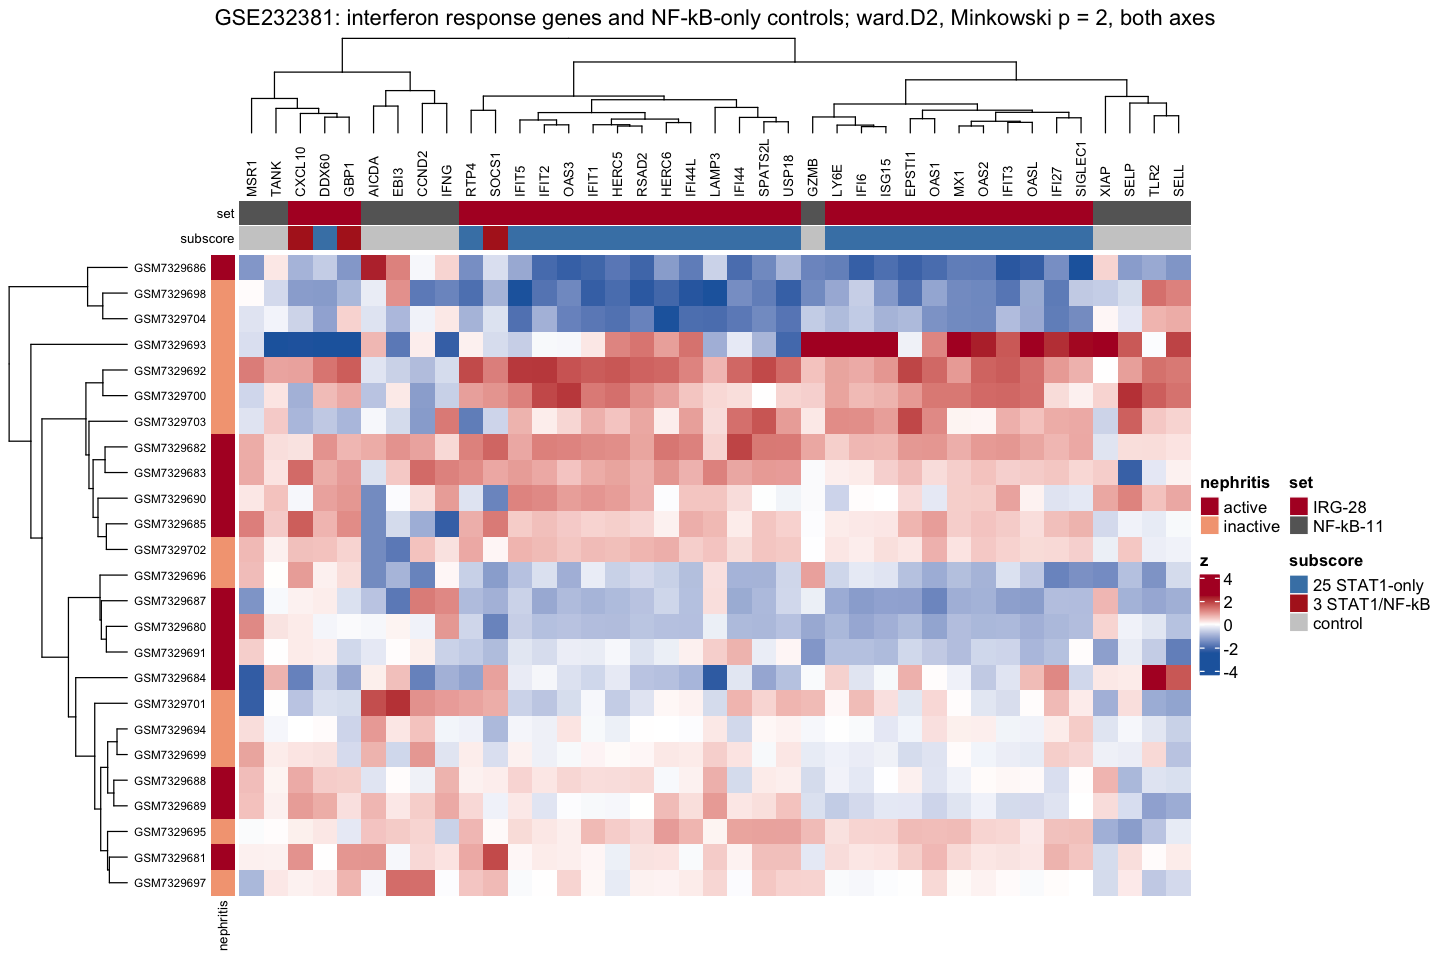

In [6]:
suppressMessages({library(ComplexHeatmap); library(circlize)})
H  <- scale(t(e$E[g$gene[g$measured], rownames(w$datExpr)]))
H  <- H[, colSums(is.na(H)) == 0]; Hc <- pmin(pmax(H, -2.5), 2.5)
hc_rows <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
hc_cols <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
gs  <- g[match(colnames(H), g$gene), ]
top <- HeatmapAnnotation(set = gs$set, subscore = ifelse(gs$set == "IRG-28", gs$dejesus2020_subscore, "control"),
                         col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40"),
                                    subscore = c("25 STAT1-only" = "steelblue", "3 STAT1/NF-kB" = "firebrick", control = "grey80")),
                         annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
m <- readRDS(art(G, "metadata.rds")); m <- m[match(rownames(w$datExpr), m$sample), ]
left <- rowAnnotation(nephritis = ifelse(m$ln_active == 1, "active", "inactive"),
                      col = list(nephritis = c(active = "#B2182B", inactive = "#F4A582")),
                      annotation_name_gp = gpar(fontsize = 8))
figure <- function() {
  Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hc_rows, cluster_columns = hc_cols,
          row_dend_side = "left", column_dend_side = "top",
          row_dend_width = unit(25, "mm"), column_dend_height = unit(20, "mm"),
          show_row_names = TRUE, row_names_side = "left", row_names_gp = gpar(fontsize = 7),
          column_names_side = "top", column_names_gp = gpar(fontsize = 8),
          top_annotation = top, left_annotation = left,
          column_title = sprintf("%s: interferon response genes and NF-kB-only controls; ward.D2, Minkowski p = 2, both axes", G))
}
options(repr.plot.width = 12, repr.plot.height = 8)
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig(G, "15c_interferon_heatmap.png"), width = 12, height = 8, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `library(ComplexHeatmap)` draws heatmaps with dendrograms and annotation strips (Gu Z, Eils R, Schlesner M.
  Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics*
  2016;32:2847-2849). `library(circlize)` provides `colorRamp2()`, which maps numbers to colours (Gu Z, Gu L,
  Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics*
  2014;30:2811-2812).
- `e$E[g$gene[g$measured], rownames(w$datExpr)]` takes the measured interferon and control genes for the 25 samples,
  the samples of this study's network. `t()` makes the samples the rows; `scale()` z-scores each gene. Genes
  that do not vary are dropped. `Hc` caps the colours at -2.5 and 2.5, as in notebook 07.
- `hc_rows` and `hc_cols` are Ward trees (`ward.D2`, Minkowski p = 2) of the samples and of the genes, as in
  notebook 07. The trees are drawn whole.
- `top` marks each gene's set (the 28 interferon response genes or the 11 NF-kB-only controls) and its
  subscore in de Jesus 2020 (25 STAT1-only, or 3 STAT1 and NF-kB).
- `left` shows nephritis activity (notebook 11), next to the sample tree and sample identifiers.
- The figure loop is explained in notebook 04.

**Result.** In the gene tree, the first split separates CXCL10, DDX60 and GBP1 with six controls (AICDA,
CCND2, EBI3, IFNG, MSR1, TANK) from the other 25 interferon response genes with five controls (GZMB, SELP,
TLR2, SELL, XIAP). In the samples' tree, the first split separates 3 samples with low interferon genes
(1 active, 2 inactive) from 22 (11 active, 11 inactive).

## Figure

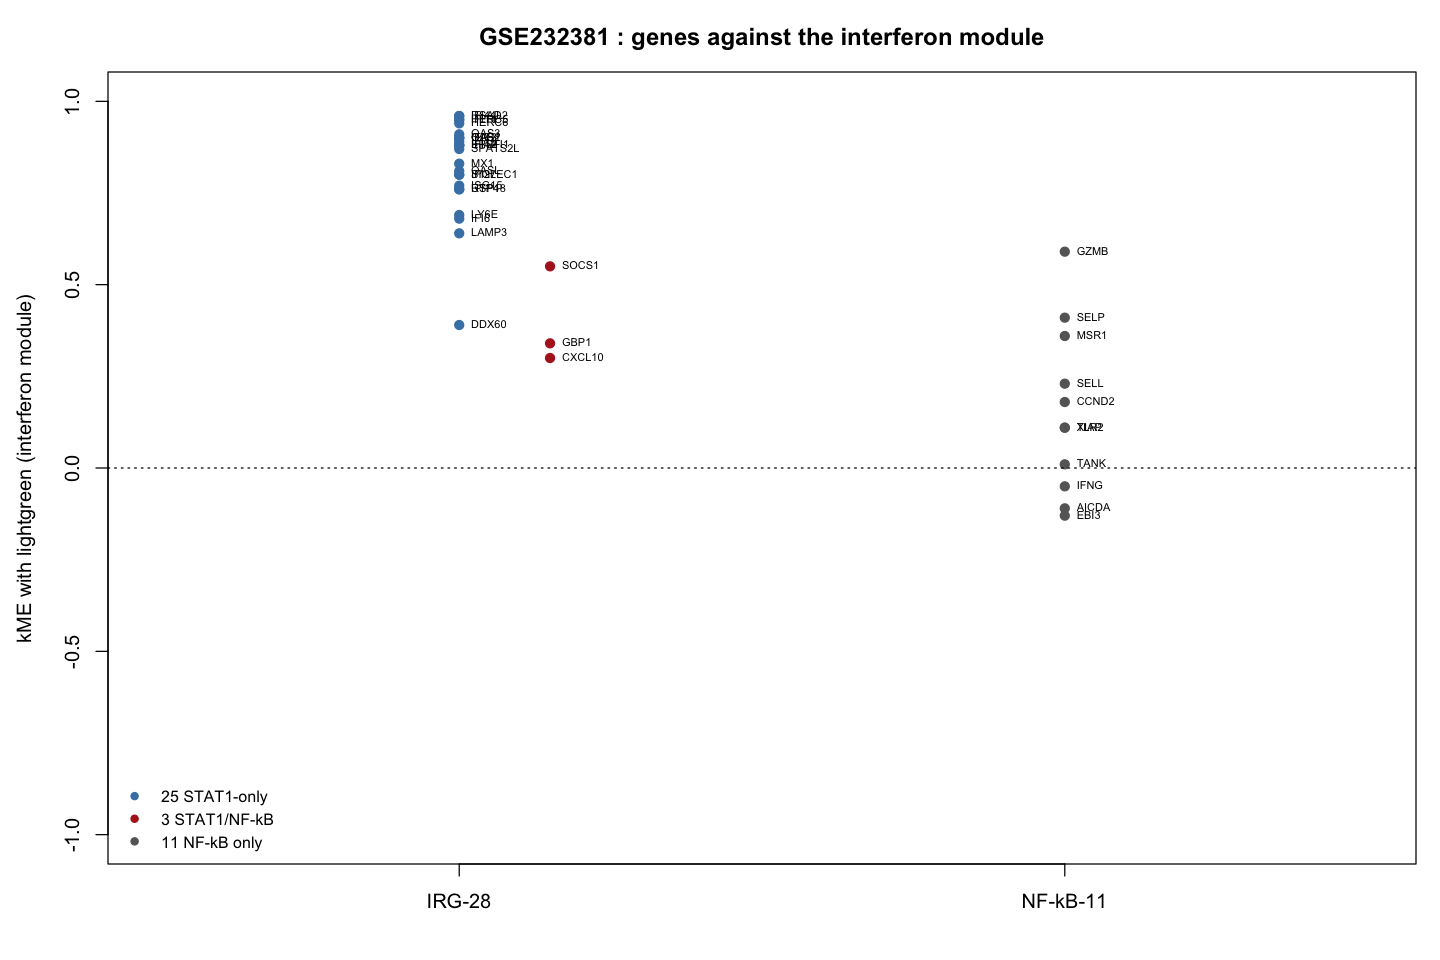

In [7]:
figure <- function() {
  d <- g[g$in_network, ]
  d$x <- ifelse(d$set == "IRG-28", 1, 2) + ifelse(d$dejesus2020_subscore == "3 STAT1/NF-kB", 0.15, 0)
  par(mar = c(4, 4.5, 3, 1))
  plot(d$x, d$kME_ifn, xlim = c(0.5, 2.5), ylim = c(-1, 1), xaxt = "n", pch = 19,
       col = ifelse(d$set == "NF-kB-11", "grey40", ifelse(d$dejesus2020_subscore == "3 STAT1/NF-kB", "firebrick", "steelblue")),
       xlab = "", ylab = paste0("kME with ", ifn_module, " (interferon module)"),
       main = paste(G, ": genes against the interferon module"))
  axis(1, at = 1:2, labels = c("IRG-28", "NF-kB-11")); abline(h = 0, lty = 3)
  text(d$x, d$kME_ifn, d$gene, pos = 4, cex = 0.55)
  legend("bottomleft", c("25 STAT1-only", "3 STAT1/NF-kB", "11 NF-kB only"), pch = 19,
         col = c("steelblue", "firebrick", "grey40"), bty = "n", cex = 0.8)
}
for (device in c("inline", "png")) {
  if (device == "png") png(fig(G, "15c_interferon_genes.png"), width = 7, height = 7, units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `figure()` draws one point per gene in the network: its kME with the interferon module (vertical axis),
  the 28 interferon response genes on the left and the 11 control genes on the right.
- Colours: blue for the 25 STAT1-only genes, red for CXCL10, GBP1 and SOCS1, grey for the controls.
- The loop draws the figure twice: once in the notebook, and once into a 300 dpi PNG in `figures/`
  (notebook 04 explains this loop).